In [36]:
import numpy as np
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, PowerTransformer,
    OneHotEncoder, OrdinalEncoder,FunctionTransformer)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


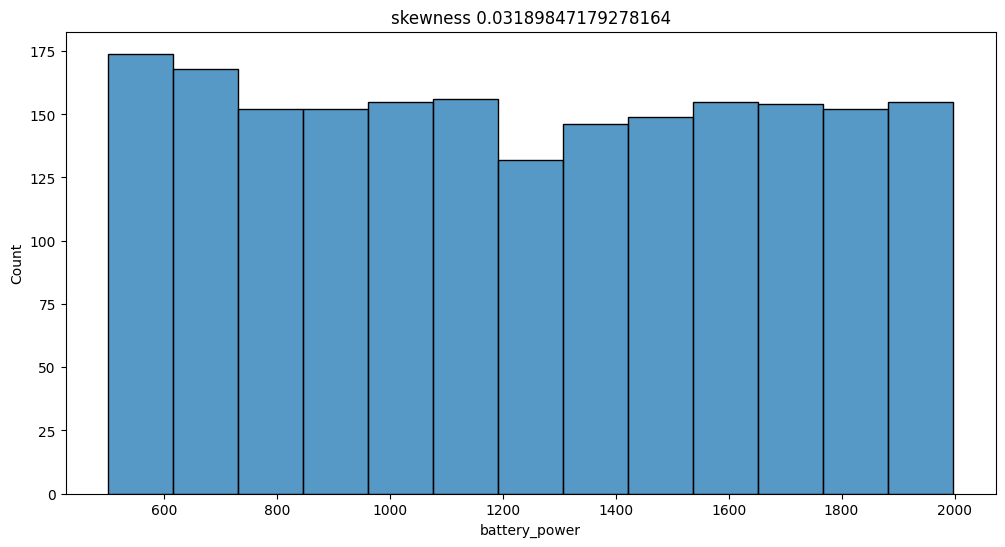

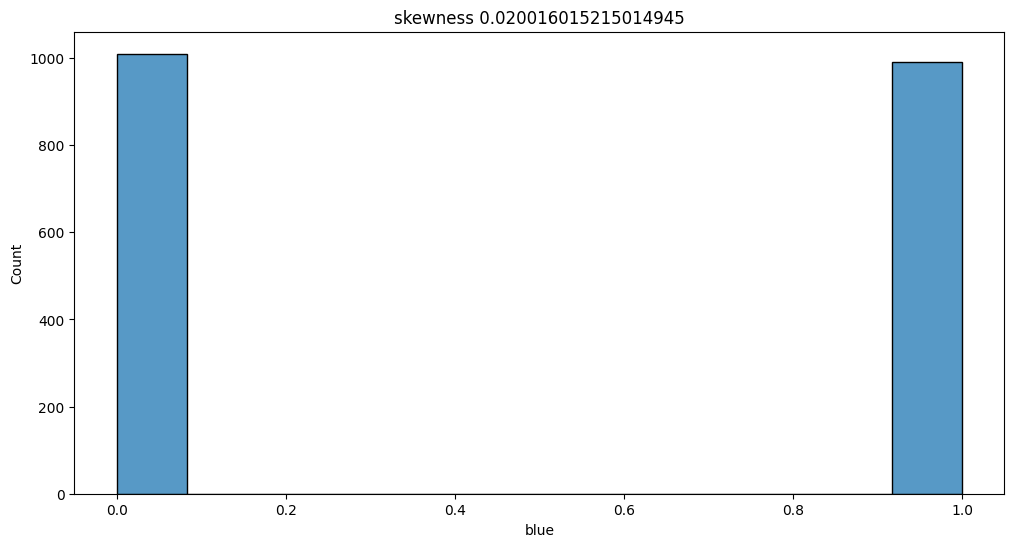

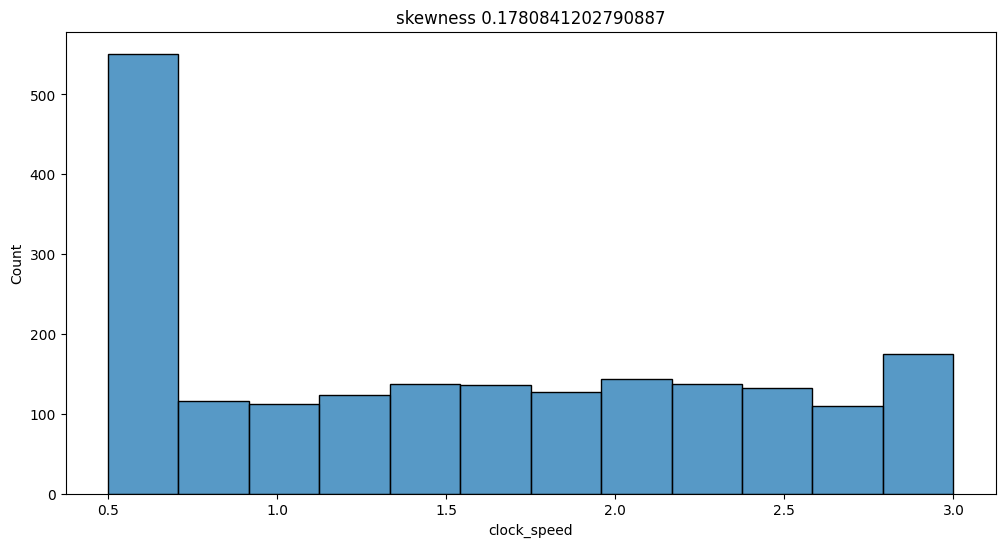

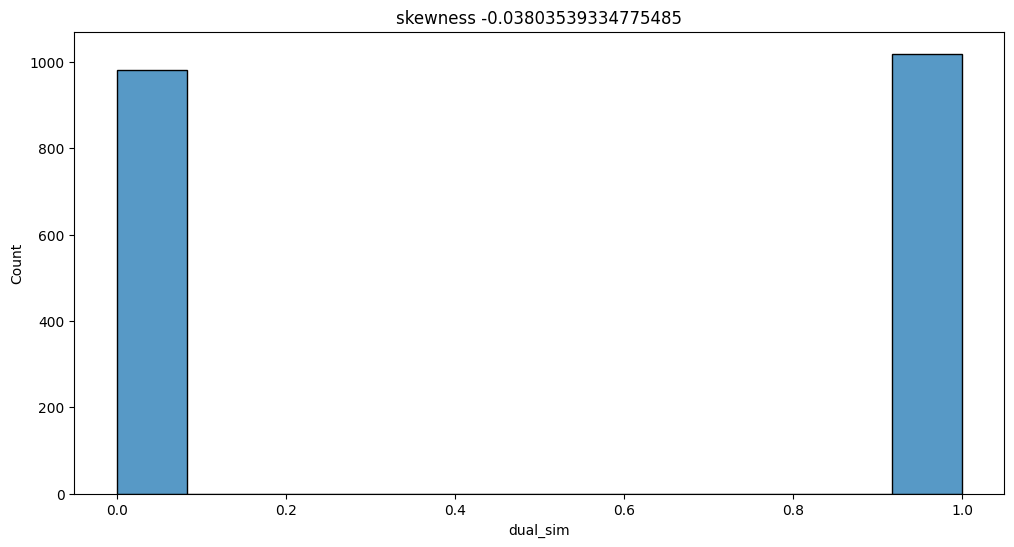

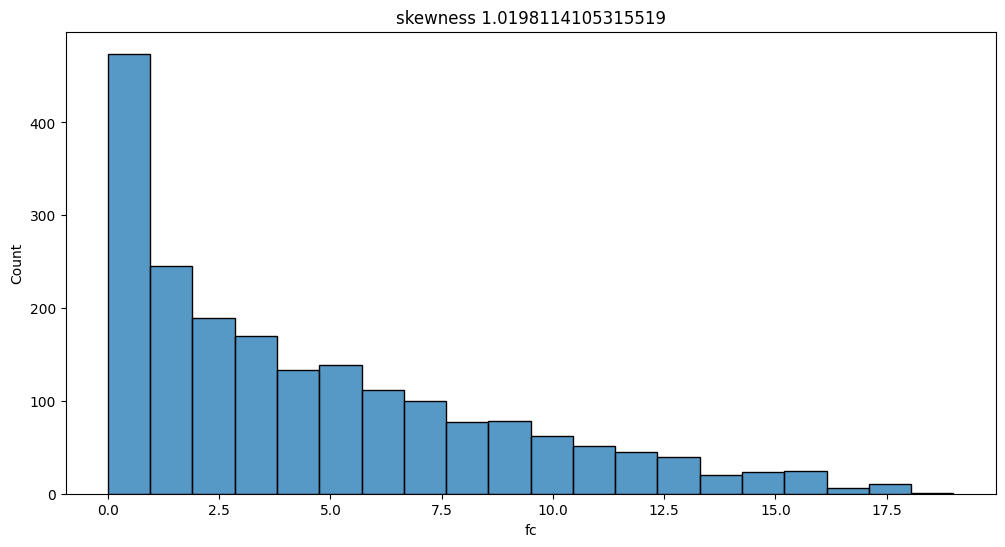

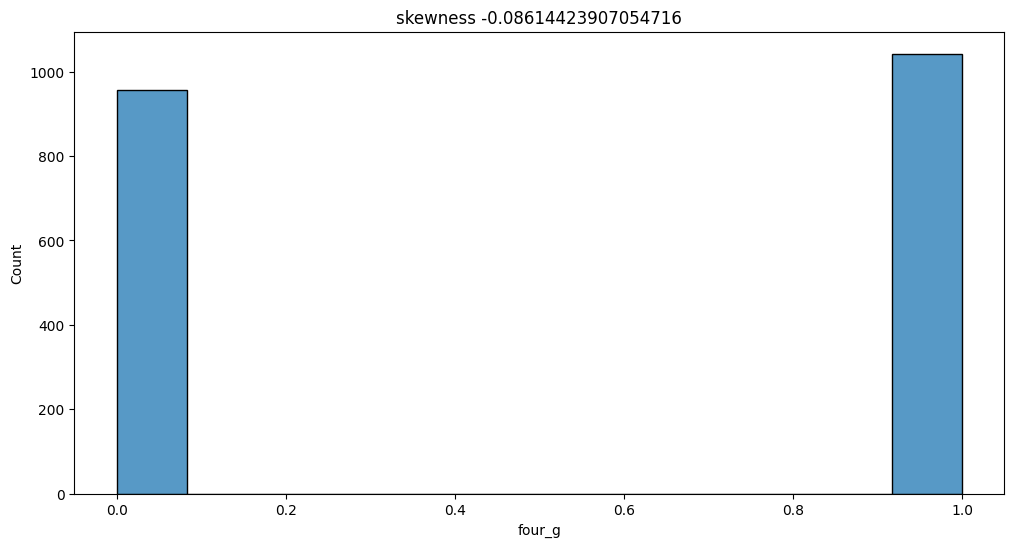

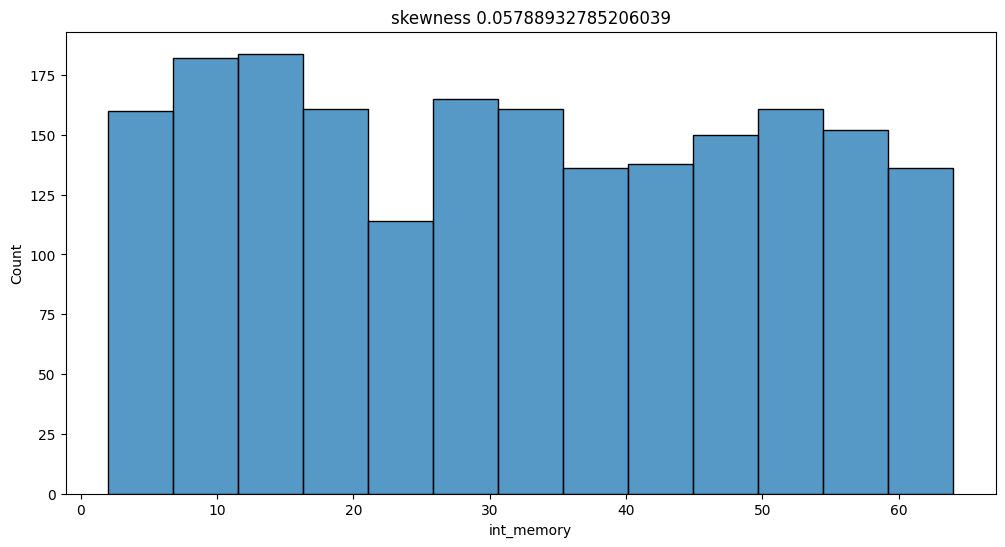

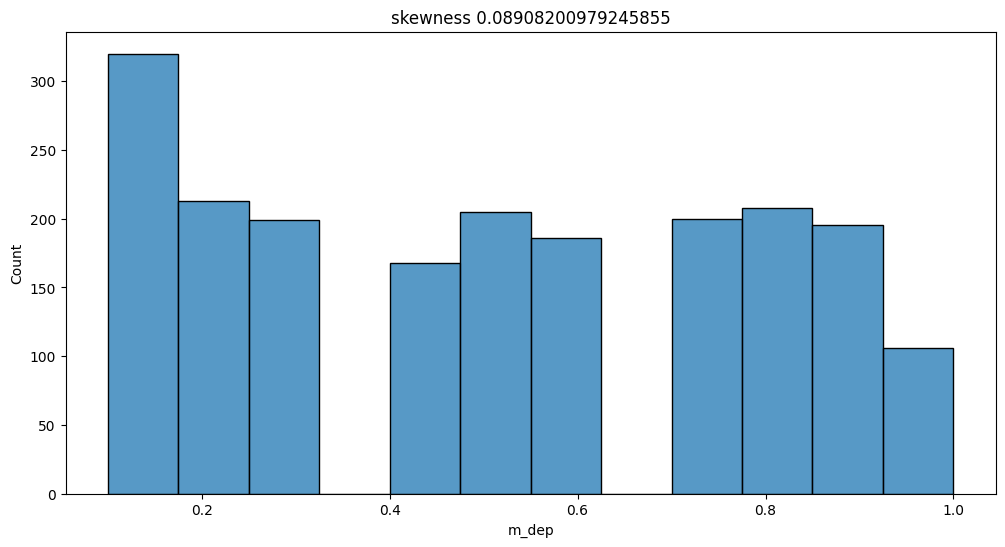

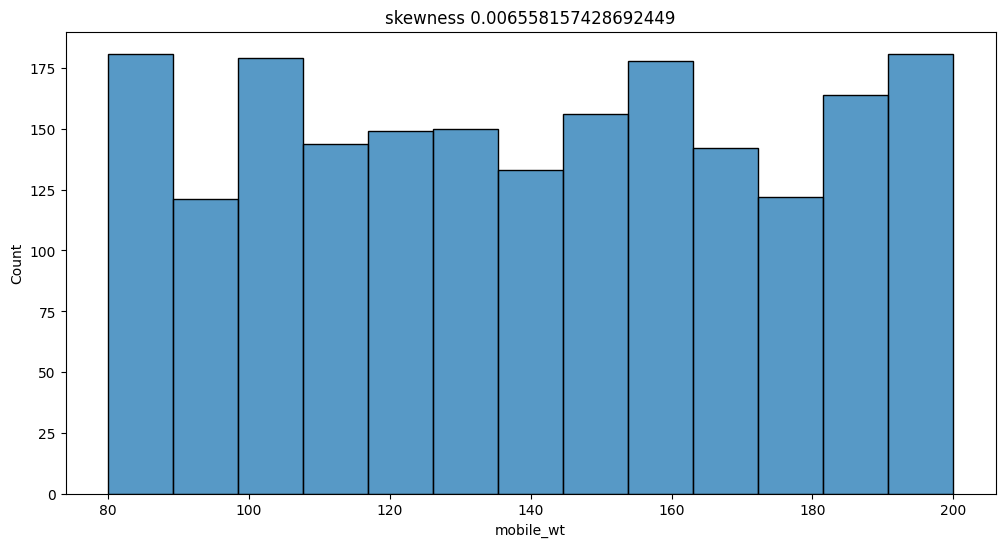

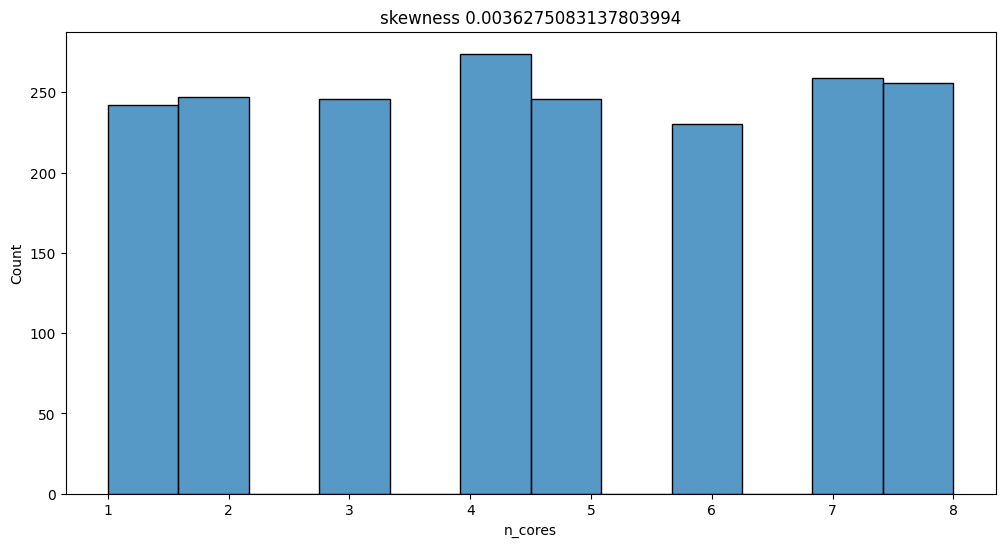

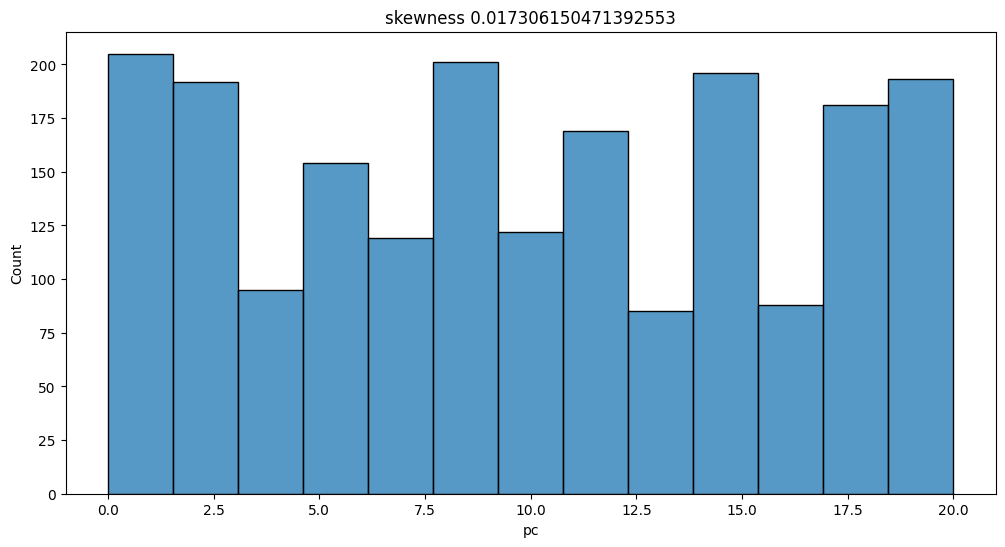

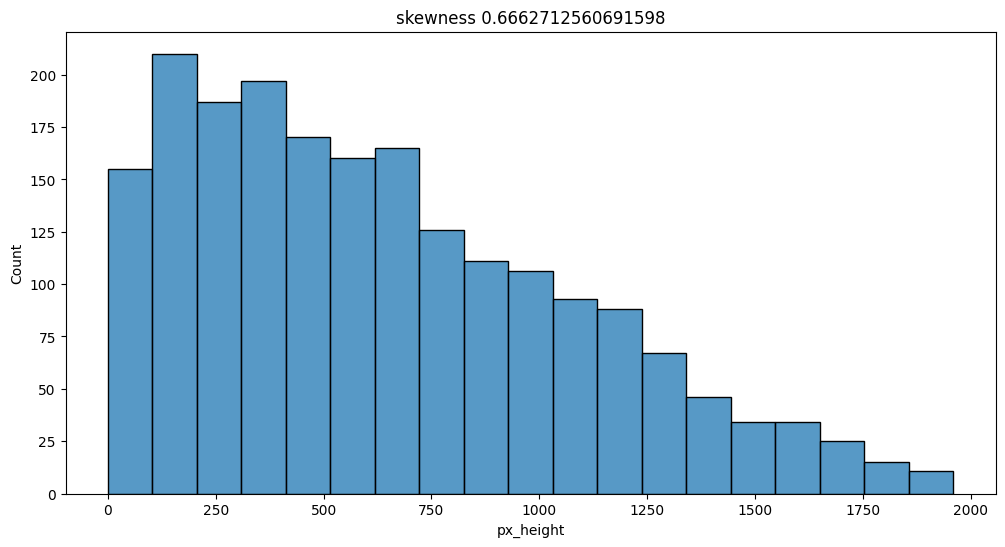

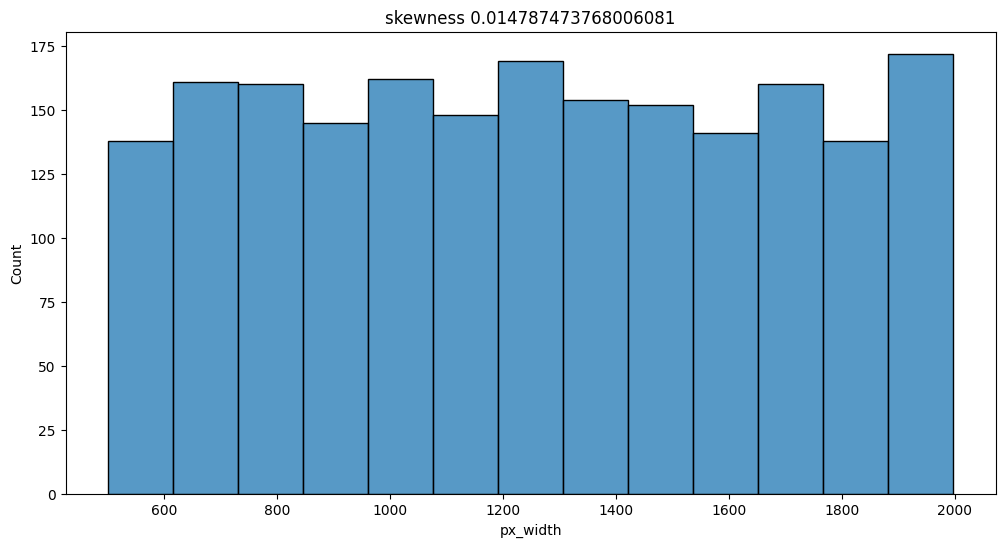

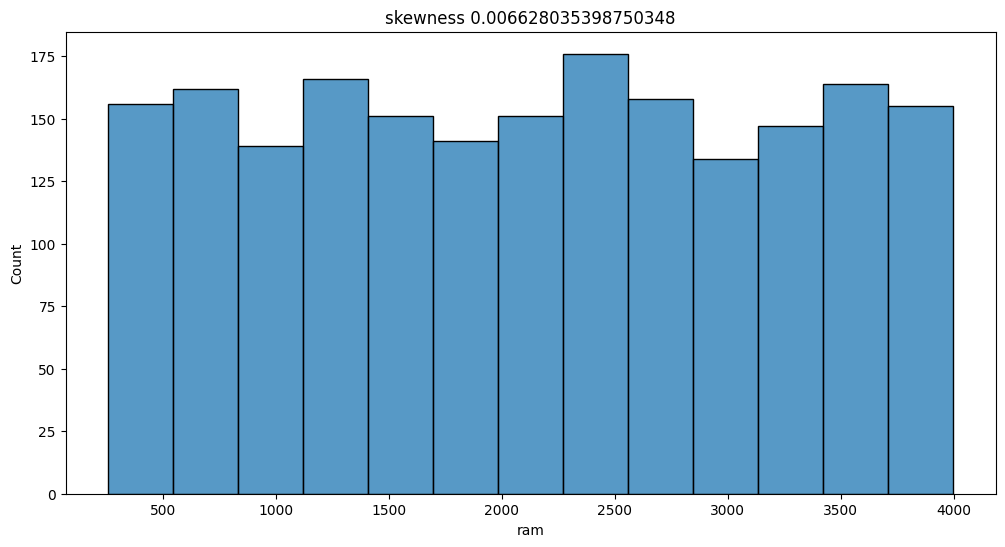

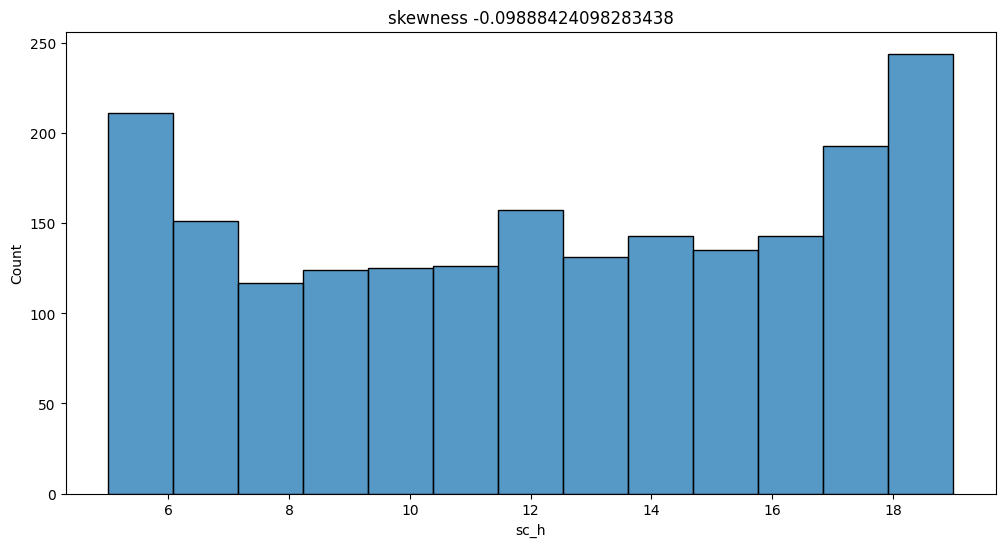

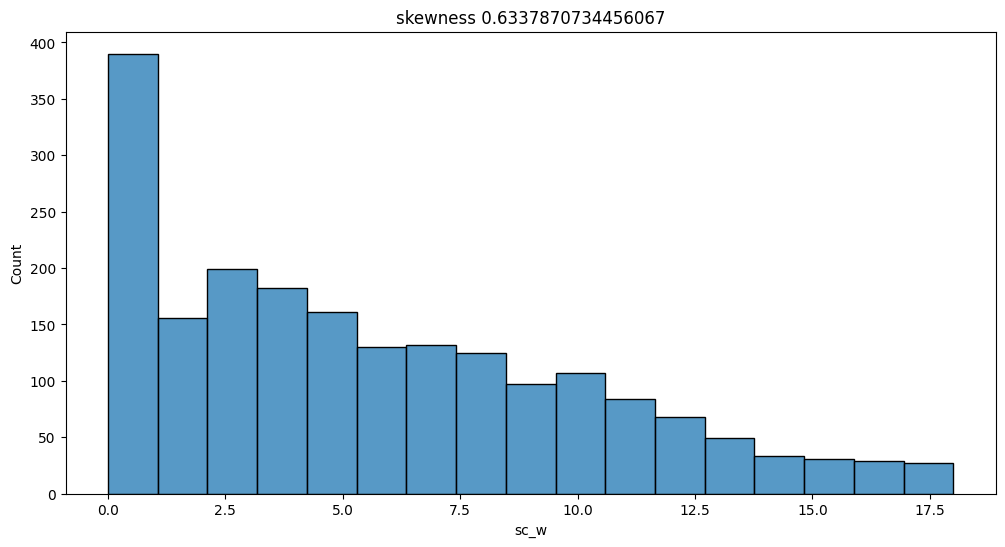

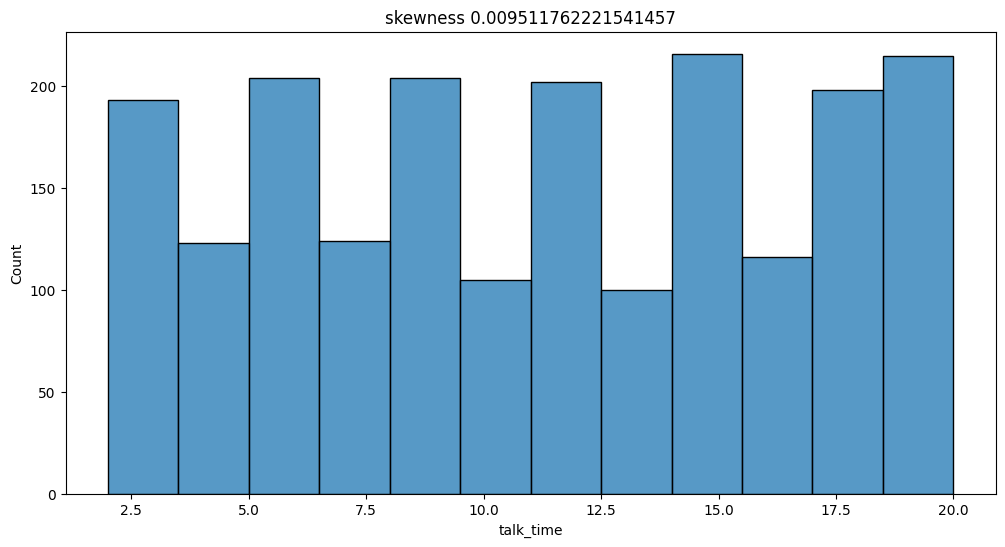

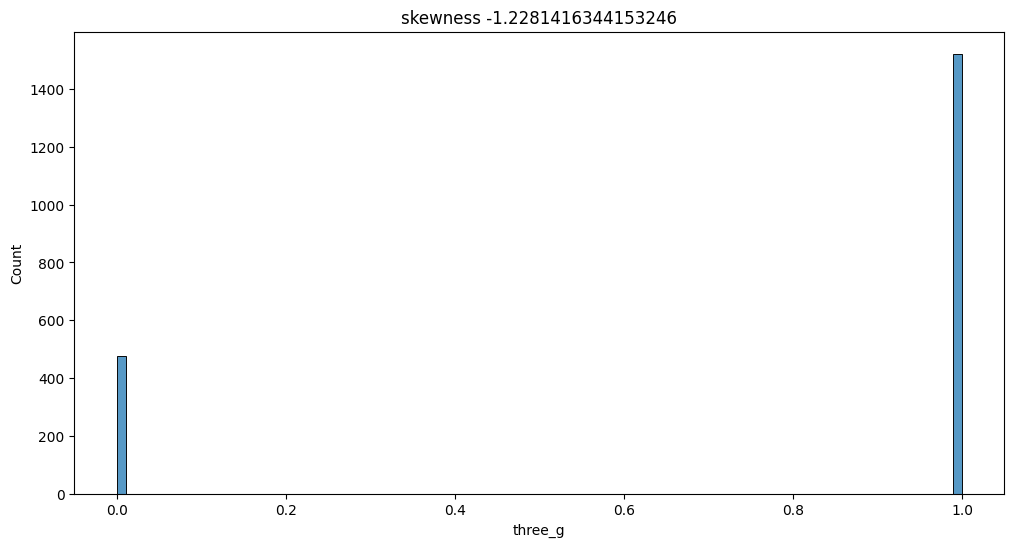

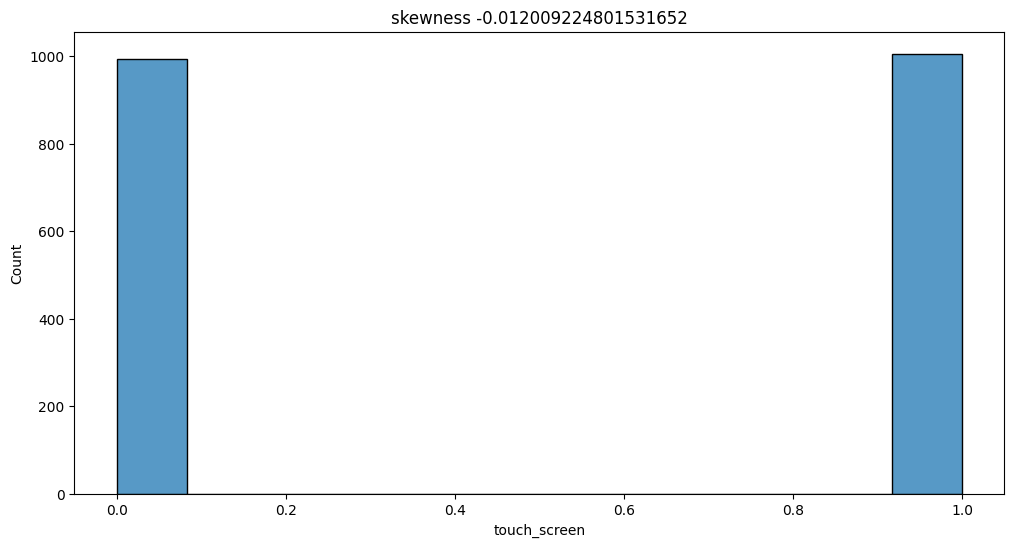

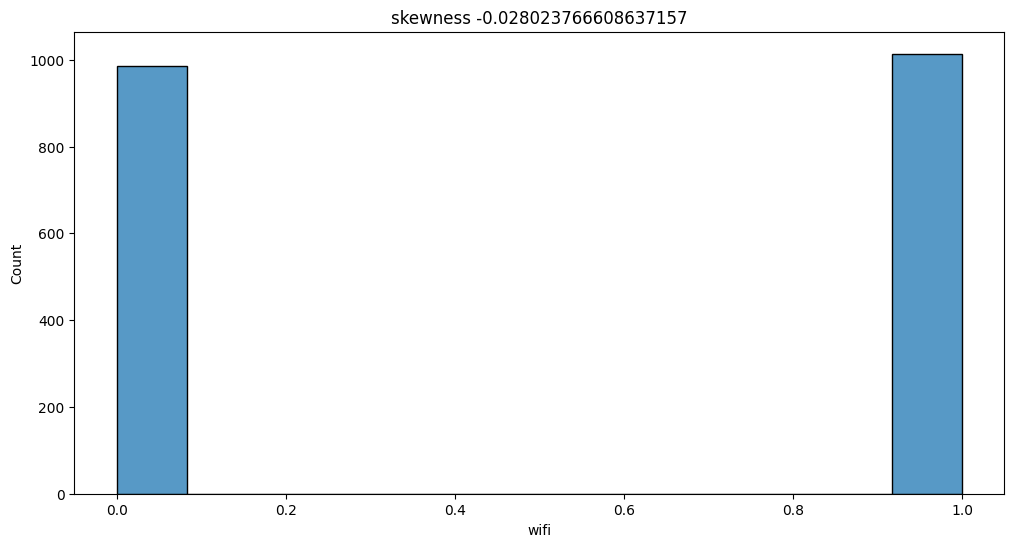

In [12]:
for col in df.columns[:-1]:
    plt.figure(figsize=(12,6))
    sns.histplot(data=df,x=col)
    plt.title(f'skewness {df[col].skew()}')
    plt.show()

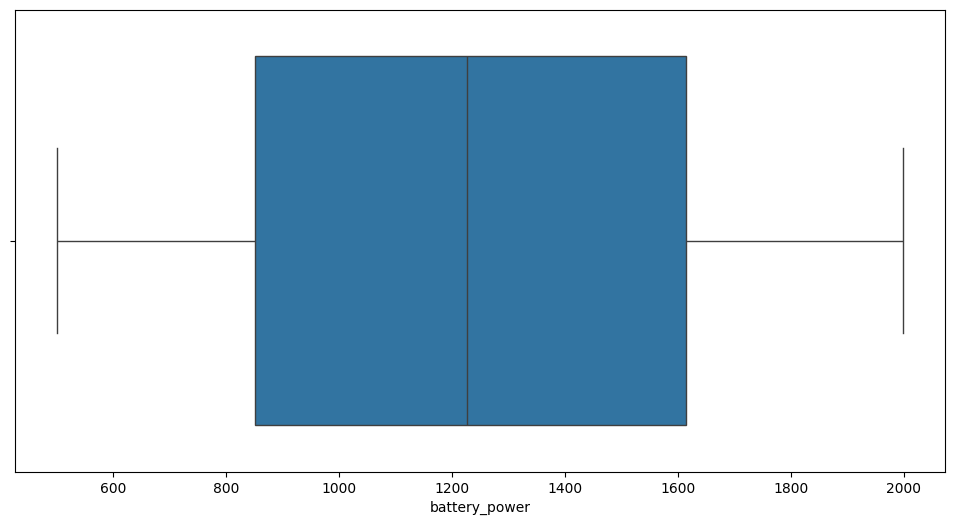

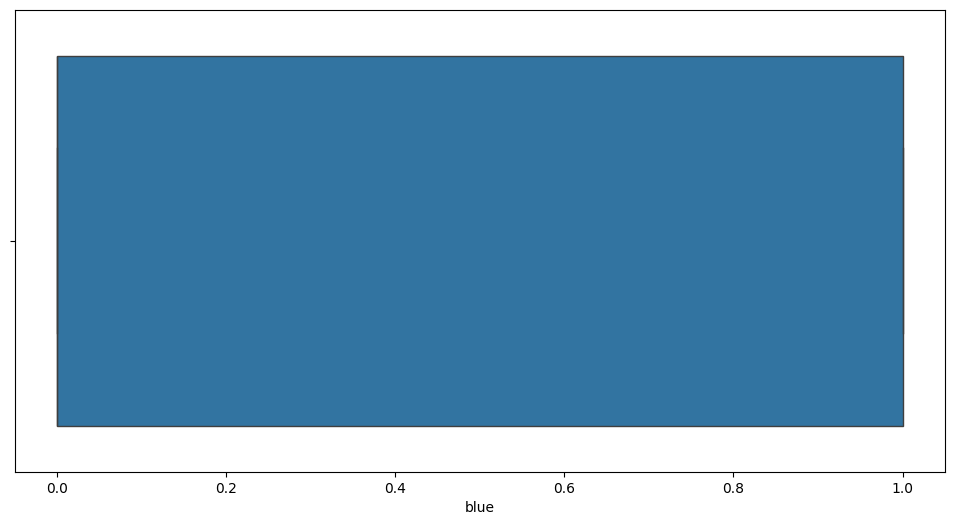

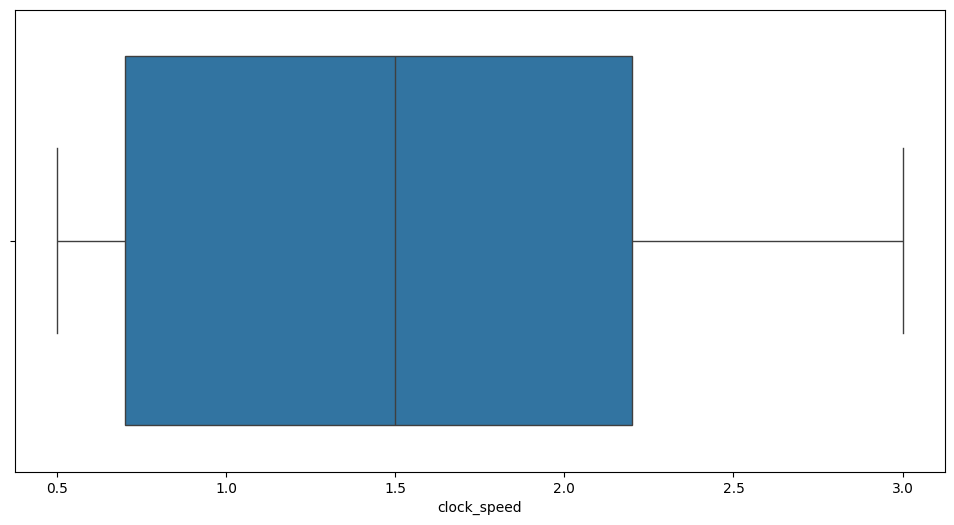

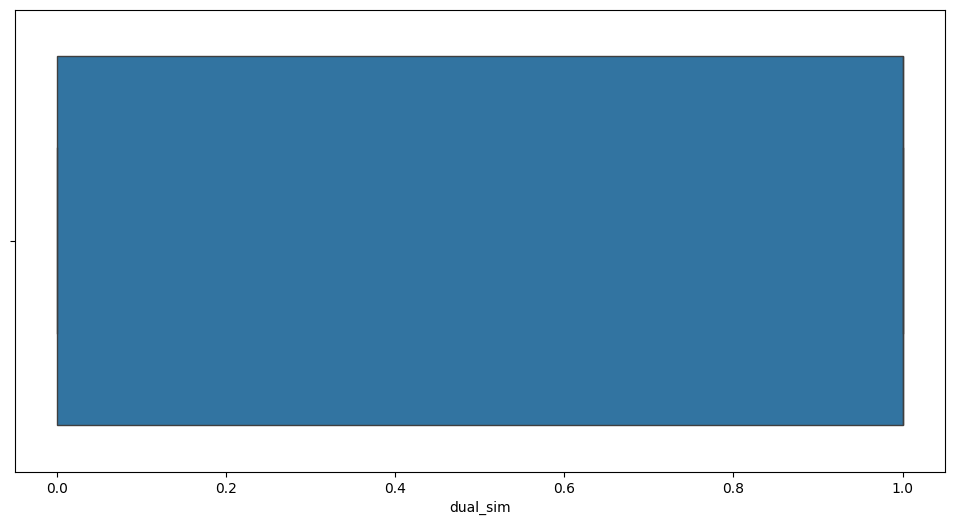

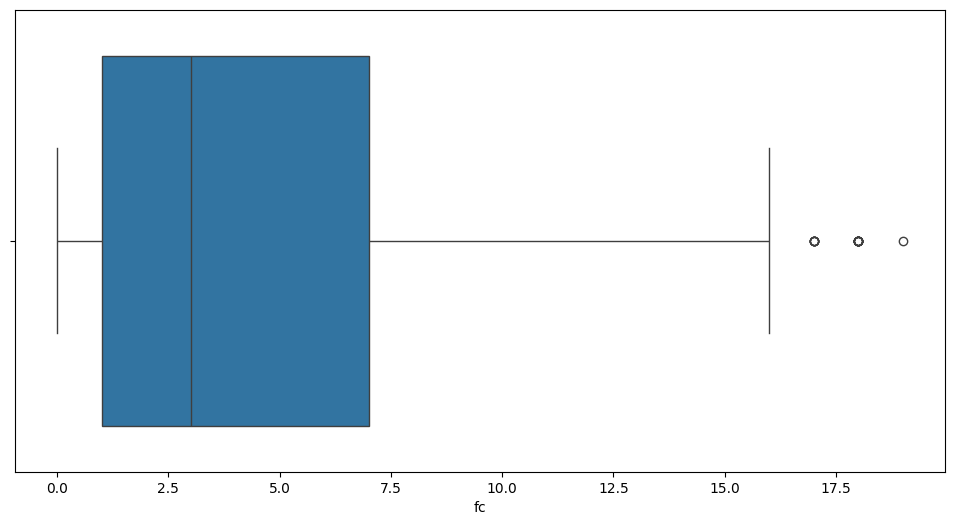

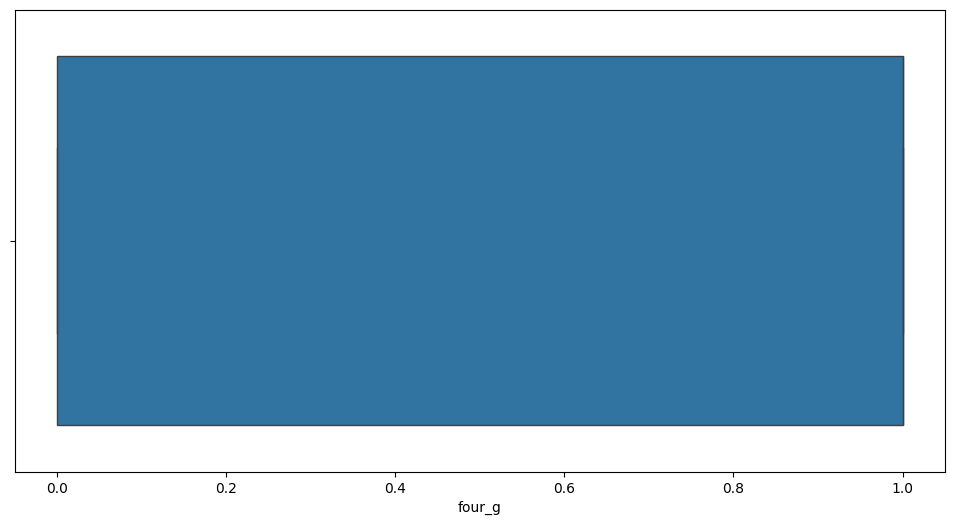

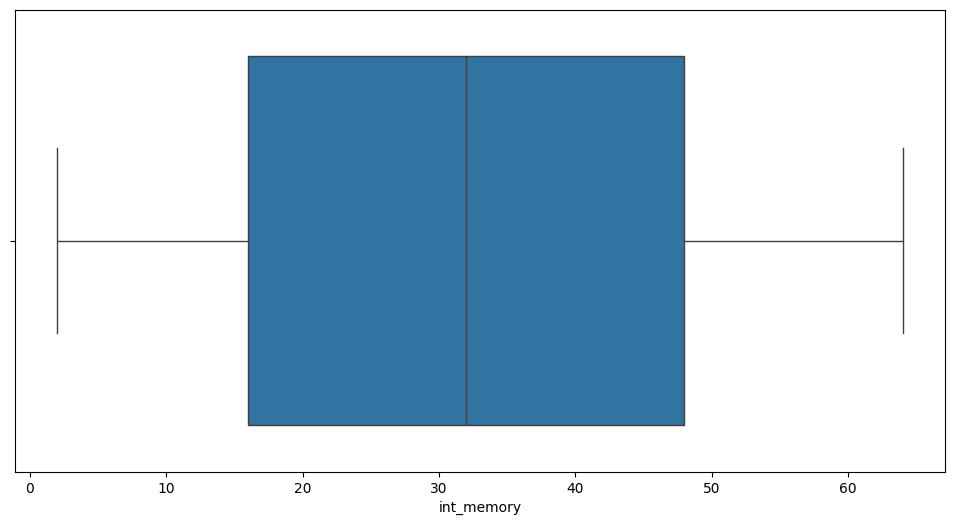

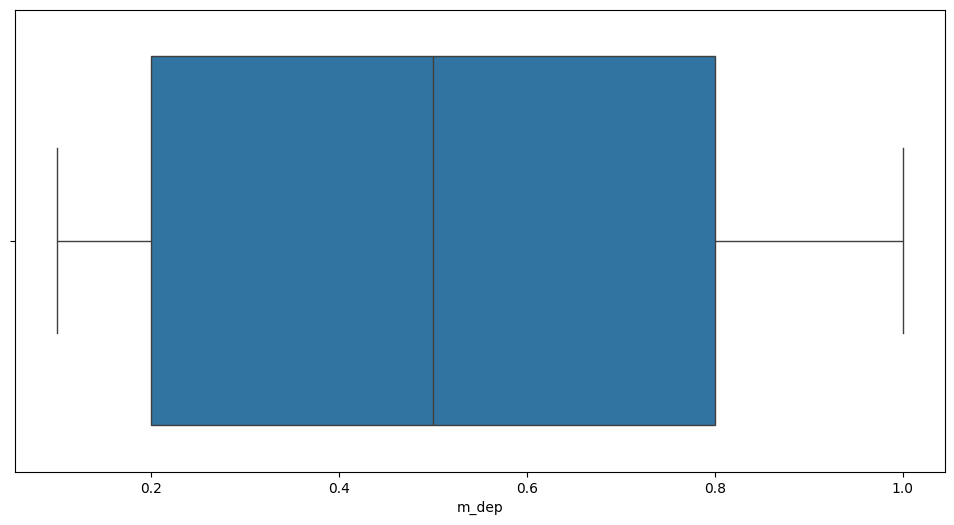

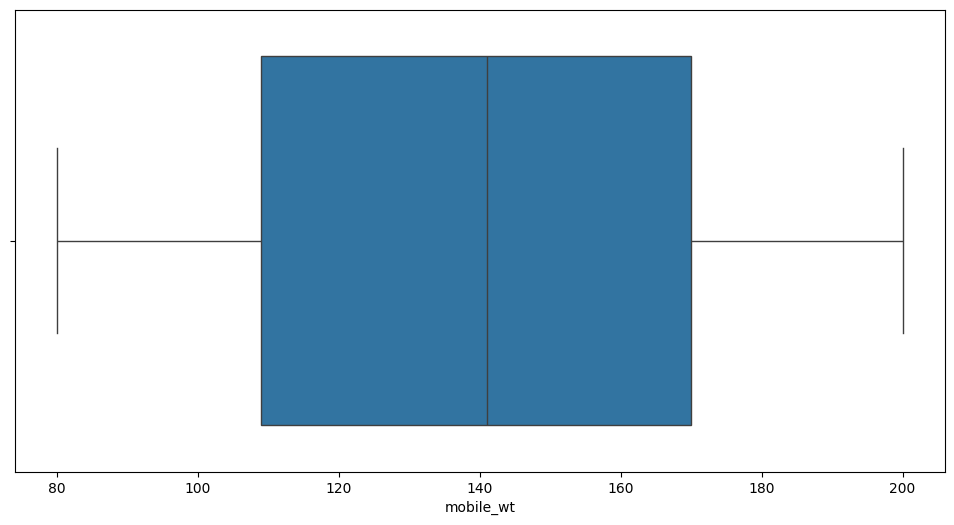

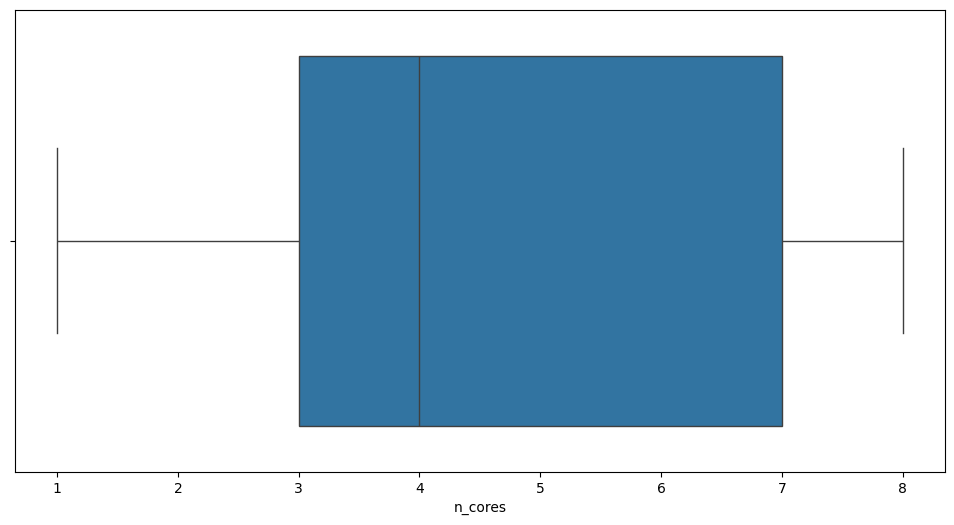

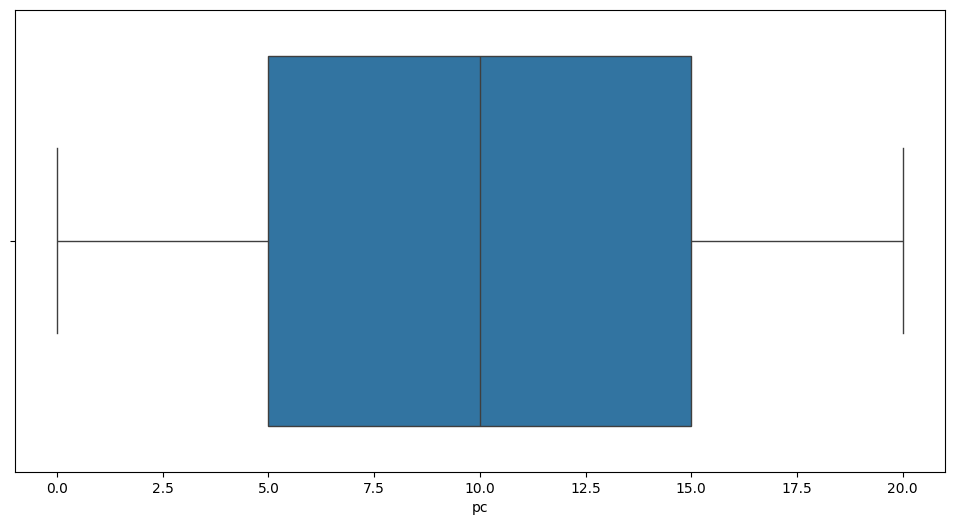

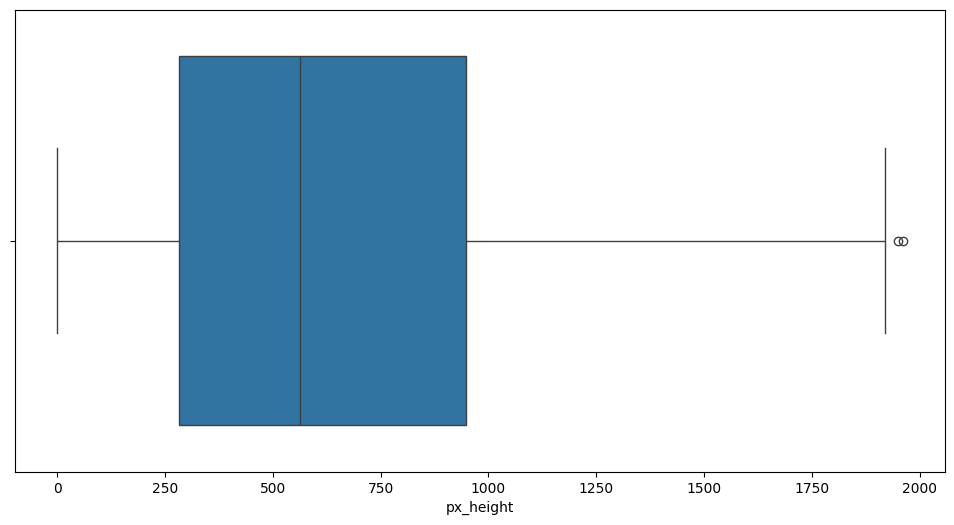

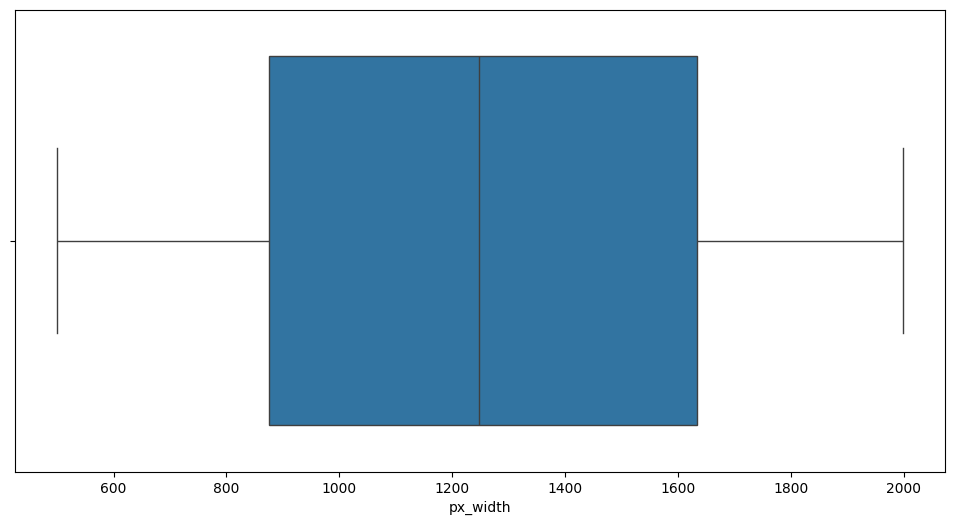

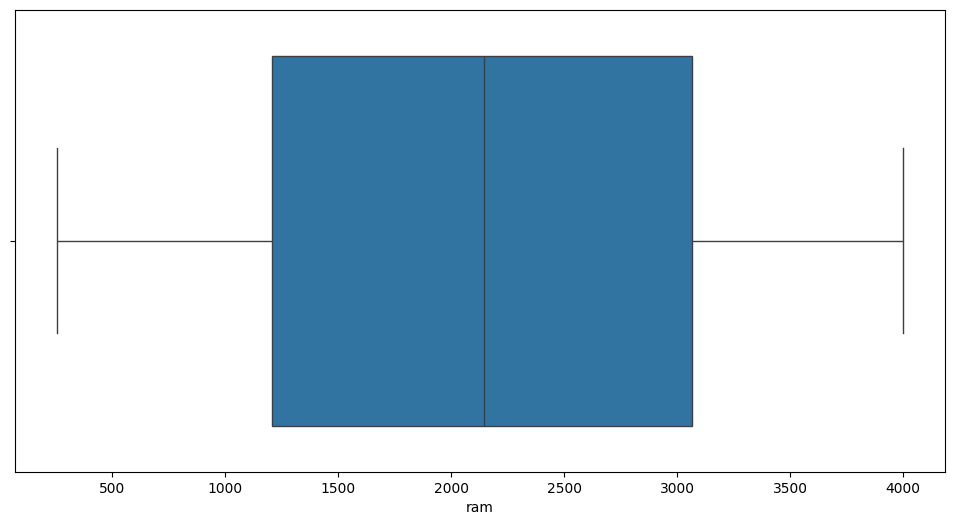

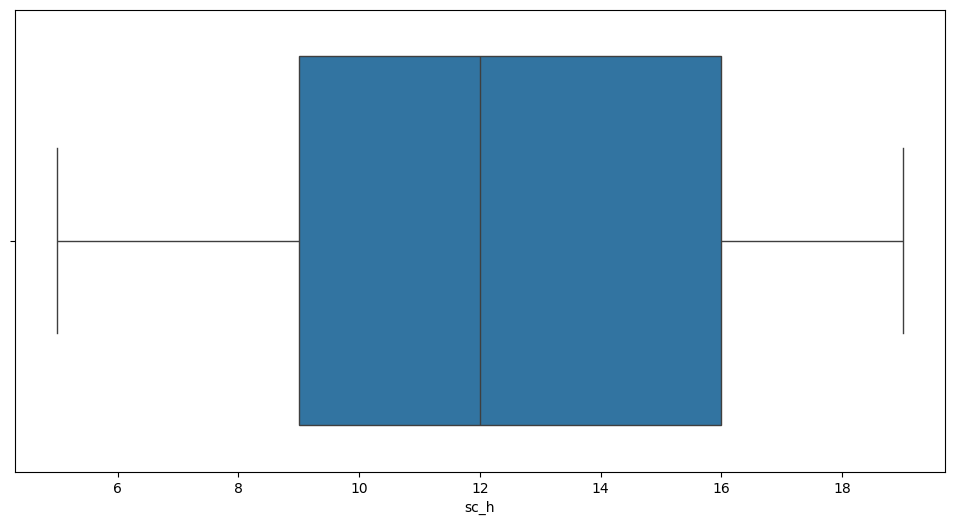

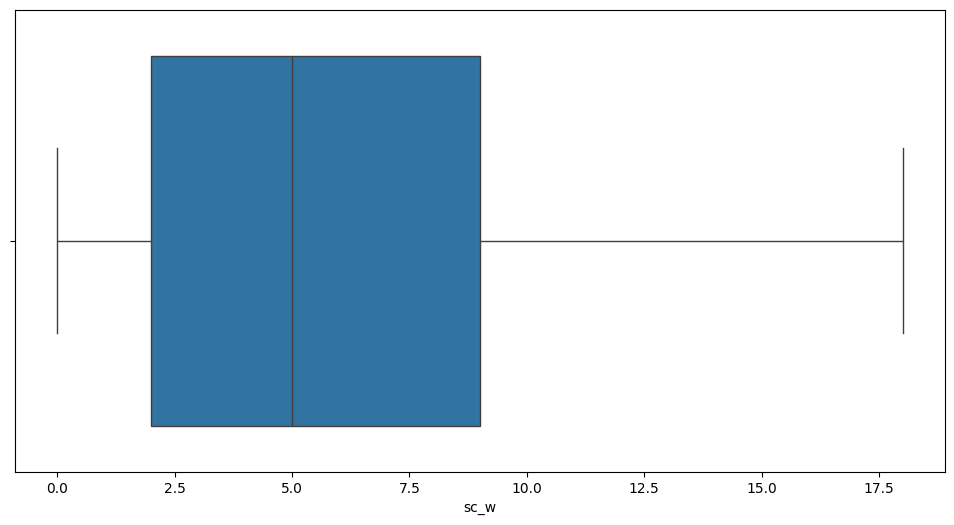

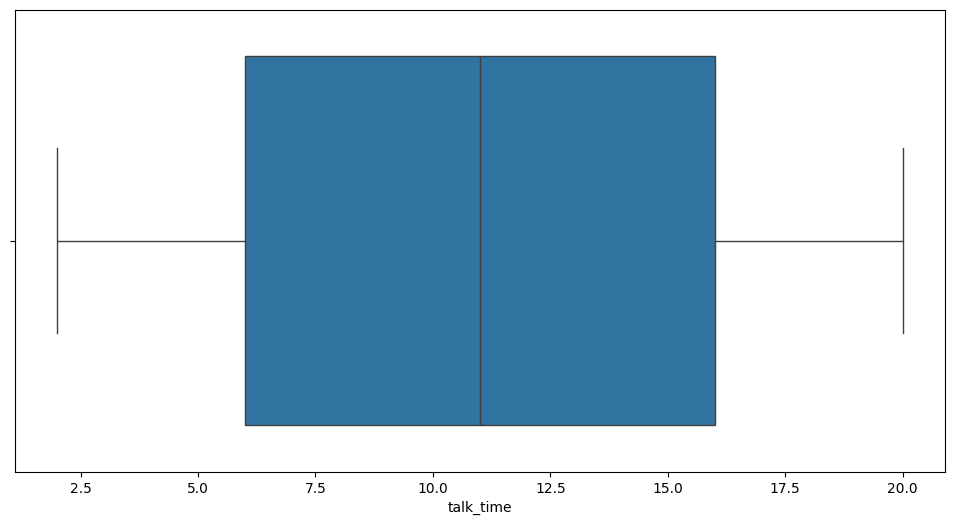

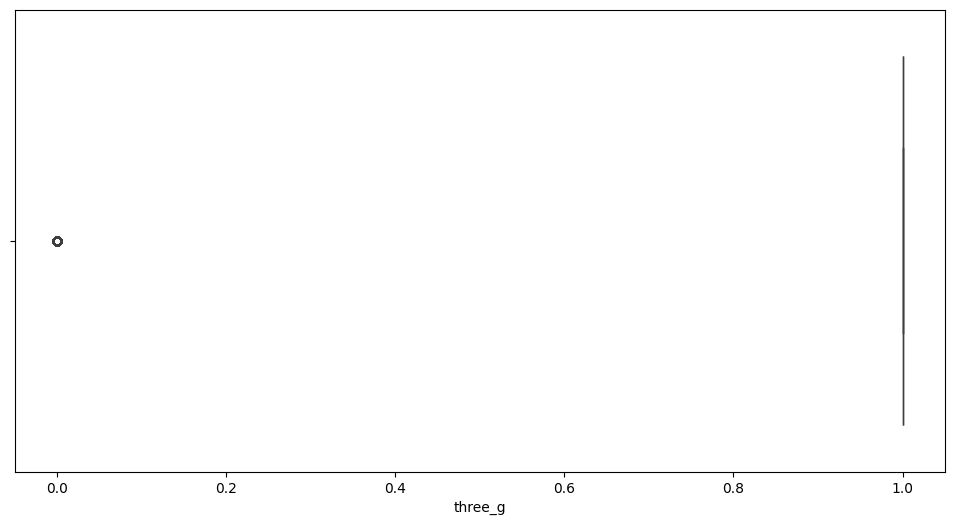

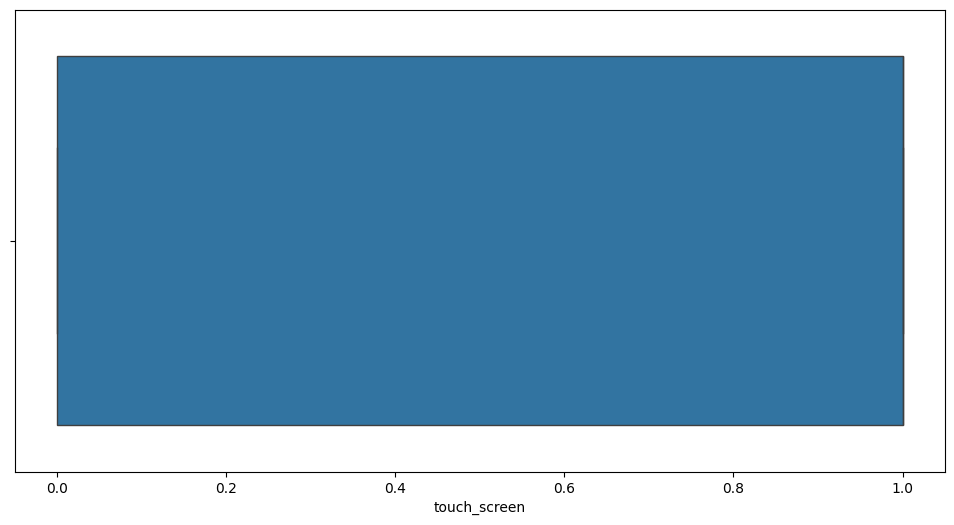

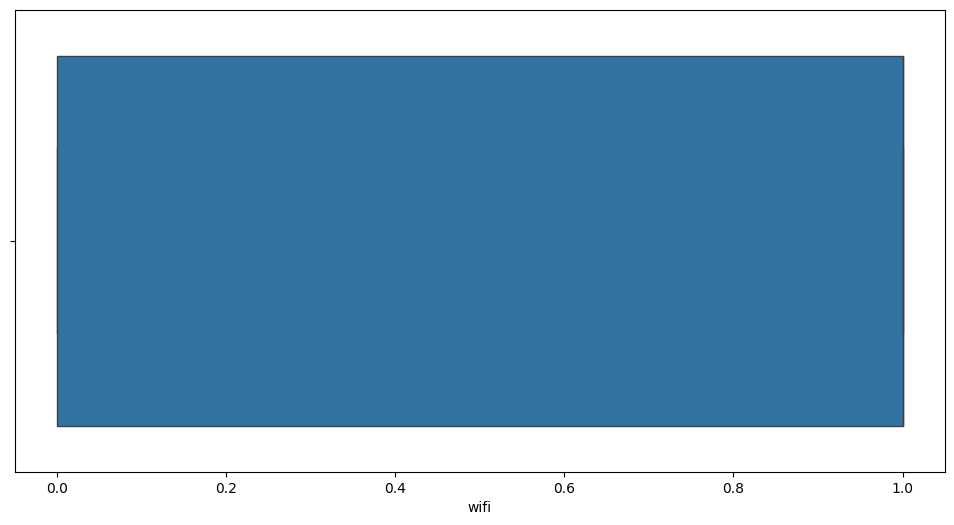

In [13]:
for col in df.columns[:-1]:
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df,x=col)
    plt.show()

In [14]:
(np.sqrt(df.fc)).skew()

np.float64(0.013144904200097396)

<Axes: xlabel='fc'>

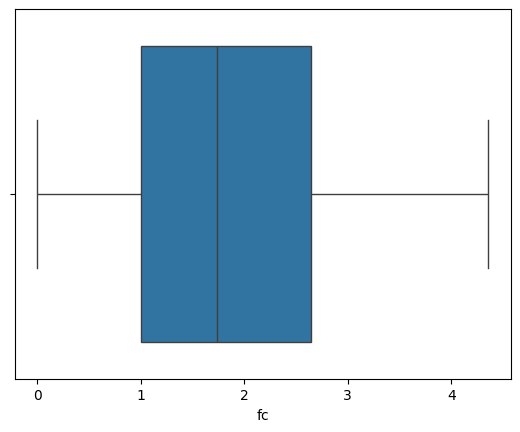

In [34]:
sns.boxplot(data=df,x=np.sqrt(df['fc']))

In [4]:
X=df.drop(df[['price_range']],axis=1)
X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [5]:
Y=df.price_range
Y.head()

0    1
1    2
2    2
3    2
4    1
Name: price_range, dtype: int64

In [8]:
numeric_normal  = ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi',]
numeric_skewed  = ['fc'] 

def skewness(x):
    return np.sqrt(x)
    
num_skewed_pipe = Pipeline([
    ('impute',  SimpleImputer(strategy='median')),
    ('power' , FunctionTransformer(skewness,validate=False)),
    ('scale',   StandardScaler())
])
num_normal_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num_normal', num_normal_pipe, numeric_normal),
    ('num_skewed', num_skewed_pipe, numeric_skewed),
], remainder='drop', verbose_feature_names_out=True)

In [22]:
def skewness(x):
    return np.sqrt(x)
    
num_skewed_pipe = Pipeline([
    ('impute',  SimpleImputer(strategy='median')),
    ('power' , FunctionTransformer(skewness,validate=False)),
    ('scale',   StandardScaler())
])
num_normal_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])


X_train, X_test, y_train, y_test = train_test_split(
    X, Y.values.ravel().astype(int), test_size=0.2, random_state=42, stratify=Y)


full_pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote',      SMOTE(random_state=42)),  
    ('model',      LogisticRegression(max_iter=2000, solver='lbfgs'))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    full_pipeline, X_train, y_train, cv=cv,
    scoring={
        'f1_macro': 'f1_macro',
        'roc_auc_ovr': 'roc_auc_ovr',
        'precision_macro': 'precision_macro'
    },
    return_train_score=True
)

print(f"CV F1:      {cv_results['test_f1_macro'].mean():.3f} ± {cv_results['test_f1_macro'].std():.3f}")
print(f"CV AUC-ROC: {cv_results['test_roc_auc_ovr'].mean():.3f}")
print(f"CV PR-AUC:  {cv_results['test_precision_macro'].mean():.3f}")

CV F1:      0.951 ± 0.009
CV AUC-ROC: 0.997
CV PR-AUC:  0.951


In [23]:

full_pipeline.fit(X_train, y_train)


y_pred_final = full_pipeline.predict(X_test)

print("\n=== FINAL TEST SET EVALUATION (All 4 Classes) ===")
print(classification_report(y_test, y_pred_final))


=== FINAL TEST SET EVALUATION (All 4 Classes) ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.97      0.97       100
           2       0.96      0.94      0.95       100
           3       0.96      0.98      0.97       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



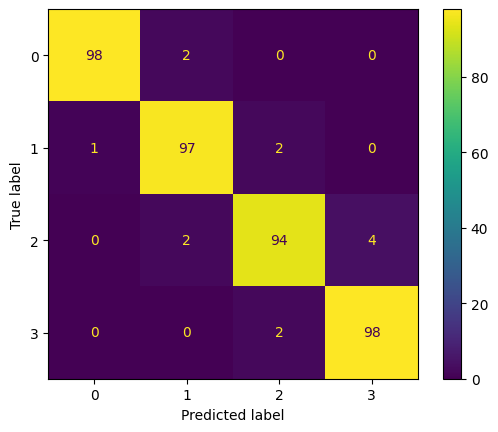

In [30]:
cm=confusion_matrix(y_test,full_pipeline.predict(X_test))
ConfusionMatrixDisplay(cm).plot()

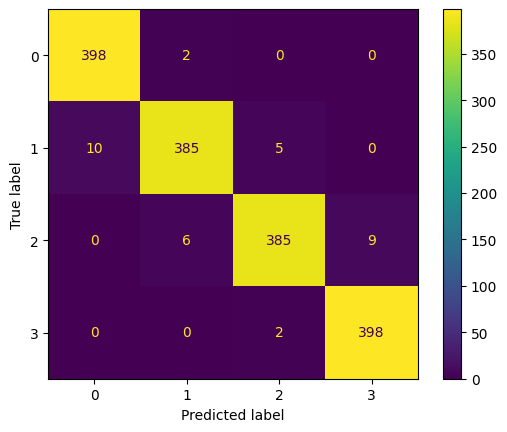

In [34]:
cm1=confusion_matrix(y_train,full_pipeline.predict(X_train))
ConfusionMatrixDisplay(cm1).plot()

In [35]:
accuracy_score(y_train,full_pipeline.predict(X_train))

0.97875

In [43]:
joblib.dump({
    'model_name': 'Mobile Price Classifier',
    'pipeline': full_pipeline,
    'accuracy': 0.96,
    'features': list(X.columns)
}, 'classification_model_mobile_pirce.pkl')

print("Success! Model saved with 93% accuracy.")

PicklingError: Can't pickle <function skewness at 0x733f6b0de7a0>: it's not the same object as __main__.skewness

In [39]:
import joblib
from datetime import datetime

# Get current date for versioning
current_date = datetime.now().strftime("%Y-%m-%d")
model_filename = f'models/mobile_model_{current_date}.pkl'

# Save the fitted pipeline
joblib.dump({
    'pipeline': full_pipeline,
    'metadata': {
        'accuracy': 0.93,
        'date': current_date,
        'features': list(X.columns)
    }
}, model_filename)

print(f"Model version saved as: {model_filename}")

FileNotFoundError: [Errno 2] No such file or directory: 'models/mobile_model_2026-04-25.pkl'

In [42]:
!pip install dill